# 03 - Customer Segmentation (RFM Analysis)
**Project:** E-Commerce Sales & Customer Analytics

This notebook segments customers using **RFM analysis** (Recency, Frequency, Monetary),
scores each customer on a 1-5 scale per dimension, and maps the combined score to
actionable business segments (Champions, Loyal Customers, At Risk, etc.).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/cleaned/ecommerce_cleaned.csv', parse_dates=['Order_Date'])
df.shape


(41262, 24)

## 1. Calculate RFM metrics

- **Recency** - days since the customer's most recent purchase (snapshot date = day after the last order in the dataset)
- **Frequency** - number of distinct orders placed by the customer
- **Monetary** - total revenue (Sales) generated by the customer


In [2]:
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)
print("Snapshot date used for Recency:", snapshot_date.date())

rfm = df.groupby('Customer_ID').agg(
    Customer_Name=('Customer_Name', 'first'),
    Recency=('Order_Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order_ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

print(f"RFM table built for {len(rfm)} unique customers")
rfm.head()


Snapshot date used for Recency: 2023-12-29
RFM table built for 3923 unique customers


,Customer_ID,Customer_Name,Recency,Frequency,Monetary
0,CUST-00001,Allison Hill,88,4,64615.80
1,CUST-00002,Noah Rhodes,39,19,348856.14
2,CUST-00003,Angie Henderson,70,5,45025.64
3,CUST-00004,Daniel Wagner,648,1,13046.74
4,CUST-00006,Connie Lawrence,155,5,43136.36


In [3]:
rfm[['Recency','Frequency','Monetary']].describe()


,Recency,Frequency,Monetary
count,3923.000000,3923.000000,3.923000e+03
mean,137.533775,10.517971,1.824710e+05
std,160.654654,20.437773,3.598063e+05
min,1.000000,1.000000,7.253000e+01
25%,25.000000,3.000000,2.738560e+04
50%,68.000000,5.000000,8.449295e+04
75%,194.000000,11.000000,2.056683e+05
max,727.000000,516.000000,8.956220e+06


## 2. Score each dimension (1-5)

Lower Recency is better (score 5), higher Frequency and Monetary are better (score 5).

In [4]:
def safe_qcut(series, q, labels, ascending=True):
    ranked = series.rank(method='first', ascending=ascending)
    return pd.qcut(ranked, q=q, labels=labels)

rfm['R_Score'] = safe_qcut(rfm['Recency'], 5, [5,4,3,2,1], ascending=True)   # low recency -> high score
rfm['F_Score'] = safe_qcut(rfm['Frequency'], 5, [1,2,3,4,5], ascending=True)  # low freq -> low score
rfm['M_Score'] = safe_qcut(rfm['Monetary'], 5, [1,2,3,4,5], ascending=True)   # low monetary -> low score

rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Sum'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

rfm.head()


,Customer_ID,Customer_Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Sum
0,CUST-00001,Allison Hill,88,4,64615.80,3,2,3,323,8
1,CUST-00002,Noah Rhodes,39,19,348856.14,4,5,5,455,14
2,CUST-00003,Angie Henderson,70,5,45025.64,3,3,2,332,8
3,CUST-00004,Daniel Wagner,648,1,13046.74,1,1,1,111,3
4,CUST-00006,Connie Lawrence,155,5,43136.36,2,3,2,232,7


## 3. Map to business segments

We keep the segmentation logic simple and business-readable rather than over-engineered:


In [5]:
def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 3 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost Customers'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm['Segment'].value_counts()


Segment
Champions              899
Lost Customers         886
Loyal Customers        777
Needs Attention        717
At Risk                345
New Customers          232
Potential Loyalists     67
Name: count, dtype: int64

## 4. Segment profile: size, revenue, and average order value

In [6]:
order_counts = df.groupby('Customer_ID')['Order_ID'].nunique()
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']

segment_profile = rfm.groupby('Segment').agg(
    Customers=('Customer_ID','count'),
    Total_Revenue=('Monetary','sum'),
    Avg_Order_Value=('AOV','mean'),
    Avg_Recency_Days=('Recency','mean'),
    Avg_Frequency=('Frequency','mean')
).sort_values('Total_Revenue', ascending=False)

segment_profile['Pct_of_Customers'] = (segment_profile['Customers'] / segment_profile['Customers'].sum() * 100).round(1)
segment_profile['Pct_of_Revenue'] = (segment_profile['Total_Revenue'] / segment_profile['Total_Revenue'].sum() * 100).round(1)
segment_profile.round(2)


,Customers,Total_Revenue,Avg_Order_Value,Avg_Recency_Days,Avg_Frequency,Pct_of_Customers,Pct_of_Revenue
Segment,,,,,,,
Champions,899,4.627112e+08,18747.57,18.15,29.06,22.9,64.6
Loyal Customers,777,1.256206e+08,18708.94,48.38,9.24,19.8,17.5
At Risk,345,5.481997e+07,21840.50,186.57,7.63,8.8,7.7
Needs Attention,717,3.899193e+07,20032.56,152.12,3.96,18.3,5.4
Lost Customers,886,1.535723e+07,9454.48,340.15,1.88,22.6,2.1
New Customers,232,1.125688e+07,18501.39,25.53,2.63,5.9,1.6
Potential Loyalists,67,7.075975e+06,39662.45,73.13,3.07,1.7,1.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_11536\3862912782.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_profile['Customers'], y=order, ax=axes[0], palette='Blues_r')
C:\Users\Admin\AppData\Local\Temp\ipykernel_11536\3862912782.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_profile['Total_Revenue'], y=order, ax=axes[1], palette='Greens_r')


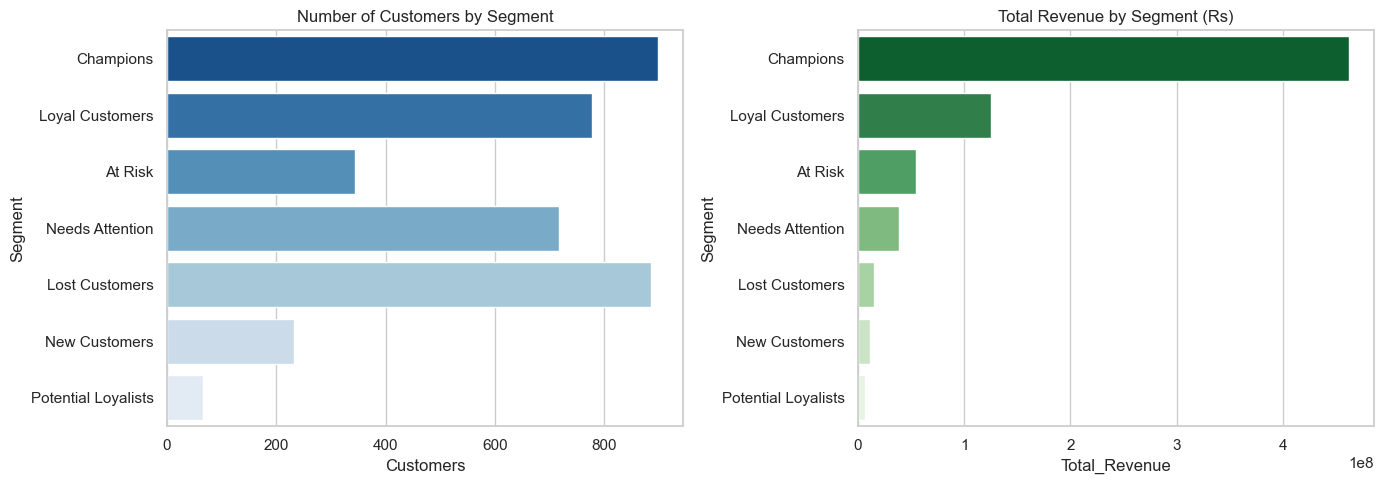

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

order = segment_profile.index
sns.barplot(x=segment_profile['Customers'], y=order, ax=axes[0], palette='Blues_r')
axes[0].set_title('Number of Customers by Segment')

sns.barplot(x=segment_profile['Total_Revenue'], y=order, ax=axes[1], palette='Greens_r')
axes[1].set_title('Total Revenue by Segment (Rs)')
plt.tight_layout()
plt.savefig('../reports/chart_rfm_segments.png', bbox_inches='tight')
plt.show()


## 5. Recommended business action per segment

In [8]:
actions = {
    'Champions': 'Reward with early access, loyalty perks, and VIP treatment - protect this high-value base.',
    'Loyal Customers': 'Upsell/cross-sell higher-margin categories; enroll in a loyalty program to push toward Champion status.',
    'Potential Loyalists': 'Encourage a second/third purchase soon with personalized offers to build the habit.',
    'New Customers': 'Onboard with a welcome series and a time-limited incentive for a second purchase.',
    'At Risk': 'Send win-back campaigns with targeted discounts before they lapse completely.',
    'Needs Attention': 'Re-engage with moderate-value offers and monitor closely for churn signals.',
    'Lost Customers': 'Low-cost reactivation email only; do not over-invest marketing spend here.',
}

action_df = pd.DataFrame({'Segment': actions.keys(), 'Recommended_Action': actions.values()}).set_index('Segment')
segment_profile.join(action_df)[['Customers','Pct_of_Customers','Total_Revenue','Pct_of_Revenue','Recommended_Action']]


,Customers,Pct_of_Customers,Total_Revenue,Pct_of_Revenue,Recommended_Action
Segment,,,,,
Champions,899,22.9,4.627112e+08,64.6,"Reward with early access, loyalty perks, and V..."
Loyal Customers,777,19.8,1.256206e+08,17.5,Upsell/cross-sell higher-margin categories; en...
At Risk,345,8.8,5.481997e+07,7.7,Send win-back campaigns with targeted discount...
Needs Attention,717,18.3,3.899193e+07,5.4,Re-engage with moderate-value offers and monit...
Lost Customers,886,22.6,1.535723e+07,2.1,Low-cost reactivation email only; do not over-...
New Customers,232,5.9,1.125688e+07,1.6,Onboard with a welcome series and a time-limit...
Potential Loyalists,67,1.7,7.075975e+06,1.0,Encourage a second/third purchase soon with pe...


## 6. Save RFM output for use in SQL / Power BI

In [9]:
rfm_export = rfm[['Customer_ID','Customer_Name','Recency','Frequency','Monetary','R_Score','F_Score','M_Score','RFM_Score','RFM_Sum','Segment']]
rfm_export.to_csv('../data/cleaned/customer_rfm_segments.csv', index=False)
print(f"Saved RFM segmentation for {len(rfm_export)} customers to data/cleaned/customer_rfm_segments.csv")
rfm_export.head()


Saved RFM segmentation for 3923 customers to data/cleaned/customer_rfm_segments.csv


,Customer_ID,Customer_Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Sum,Segment
0,CUST-00001,Allison Hill,88,4,64615.80,3,2,3,323,8,Potential Loyalists
1,CUST-00002,Noah Rhodes,39,19,348856.14,4,5,5,455,14,Champions
2,CUST-00003,Angie Henderson,70,5,45025.64,3,3,2,332,8,Needs Attention
3,CUST-00004,Daniel Wagner,648,1,13046.74,1,1,1,111,3,Lost Customers
4,CUST-00006,Connie Lawrence,155,5,43136.36,2,3,2,232,7,Needs Attention


## Summary

RFM analysis segmented **all customers** in the cleaned dataset into seven business-actionable
groups. Champions and Loyal Customers make up a minority of the customer base but generate a
disproportionate share of revenue, while a meaningful group of At Risk / Lost customers
represents a retention opportunity quantified in `reports/business_insights.md`.
